# Summer Analytics Week 2 Hackathon
## Starter Notebook

This notebook walks you through a simple end-to-end pipeline to get your first submission on the leaderboard. It covers:

- Loading the provided datasets
- Basic preprocessing (handling missing values & encoding)
- Training a **Logistic Regression** baseline model
- Generating predictions for `private_test.csv`
- Creating a valid `submission.csv`

> **Note:** This is just a starting point. Feel free to experiment and improve upon this baseline!


### Step 1: Import Libraries

We start by importing `pandas` for loading and manipulating data, and a few utilities from `scikit-learn` for preprocessing and modelling.
These are all standard libraries that come pre-installed in most Python environments like Kaggle, Colab, or Anaconda.
No additional installations are required to run this notebook.


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np


### Step 2: Load Data

We read all three CSV files — `train.csv`, `public_test.csv`, and `private_test.csv` — into pandas DataFrames.
The training set contains labelled examples we will learn from, while the private test set is what we need to make final predictions on.
Printing the shapes gives a quick sanity check that the files loaded correctly.


In [ ]:
train = pd.read_csv("train.csv")
public_test = pd.read_csv("public_test.csv")
private_test = pd.read_csv("private_test.csv")

print("Train Shape:", train.shape)
print("Public Test Shape:", public_test.shape)
print("Private Test Shape:", private_test.shape)

train.head()
train.head()
print(train.columns)


Train Shape: (10000, 14)
Public Test Shape: (3000, 14)
Private Test Shape: (3000, 13)
Index(['User_ID', 'Age', 'Income', 'City_Tier', 'Device_Type',
       'Traffic_Source', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site',
       'Previous_Purchases', 'Discount_Seen', 'Browser_Version',
       'Campaign_Code', 'Converted'],
      dtype='object')


In [ ]:
#lets do basic exploration of the dataset
print(train.info())
print('-'*30)
print('how many missing values do we have?')
print(train.isnull().sum())
print('-'*30)
print('any duplicated values?:')
print(train.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             10000 non-null  int64  
 1   Age                 8520 non-null   float64
 2   Income              9016 non-null   float64
 3   City_Tier           10000 non-null  int64  
 4   Device_Type         10000 non-null  object 
 5   Traffic_Source      10000 non-null  object 
 6   Pages_Viewed        10000 non-null  int64  
 7   Products_Viewed     10000 non-null  int64  
 8   Time_On_Site        8152 non-null   float64
 9   Previous_Purchases  10000 non-null  int64  
 10  Discount_Seen       10000 non-null  int64  
 11  Browser_Version     10000 non-null  int64  
 12  Campaign_Code       10000 non-null  int64  
 13  Converted           10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ MB
None
------------------------------
how many m

In [ ]:
print('Unique  values for Age:')
print(train['Age'].unique())
print('-'*30)
print('Unique values for Income:')
print(train['Income'].unique())
print('-'*30)
print('Unique values for Time_On_Site:')
print(train['Time_On_Site'].unique())
print('-'*30)


Unique  values for Age:
[58. 26. 19. 48. 35. 40. 21. nan 55. 51. 61. 52. 59. 49. 32. 25. 64. 62.
 31. 47. 54. 23. 42. 57. 39. 34. 28. 43. 22. 38. 18. 65. 27. 46. 63. 56.
 45. 33. 37. 30. 41. 53. 44. 50. 20. 36. 60. 29. 24.]
------------------------------
Unique values for Income:
[103593.70881175  36451.71698378  30511.22870007 ...  75347.42032785
  59311.02852609  61969.93198653]
------------------------------
Unique values for Time_On_Site:
[ 9.61 17.63 13.25 ... 21.96 24.48 22.22]
------------------------------


In [ ]:
#lets look at the count for our categorical values:
#count of our target variable !! is our data balanced!!
print(train['Converted'].value_counts())
print('-'*30)
print(train['Device_Type'].value_counts())
print('-'*30)
print(train['Traffic_Source'].value_counts())
print('-'*30)

Converted
0    6913
1    3087
Name: count, dtype: int64
------------------------------
Device_Type
Mobile     6523
Desktop    2472
Tablet     1005
Name: count, dtype: int64
------------------------------
Traffic_Source
Organic         3071
Paid Ads        2544
Social Media    1993
Referral        1456
Email            936
Name: count, dtype: int64
------------------------------


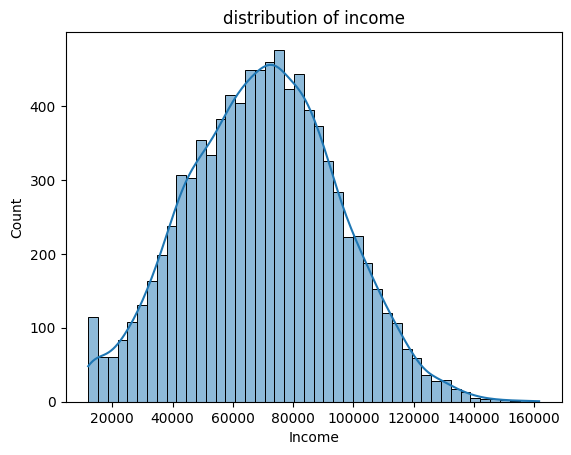

In [ ]:
#basic visualization
sns.histplot(x = 'Income', data = train , kde = True)
plt.title('distribution of income')
plt.show()

[]

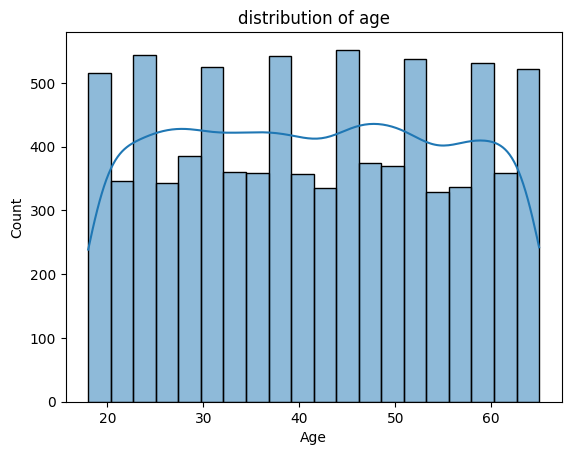

In [ ]:
sns.histplot(x = 'Age', data =train , kde = True)
plt.title('distribution of age')
plt.plot()

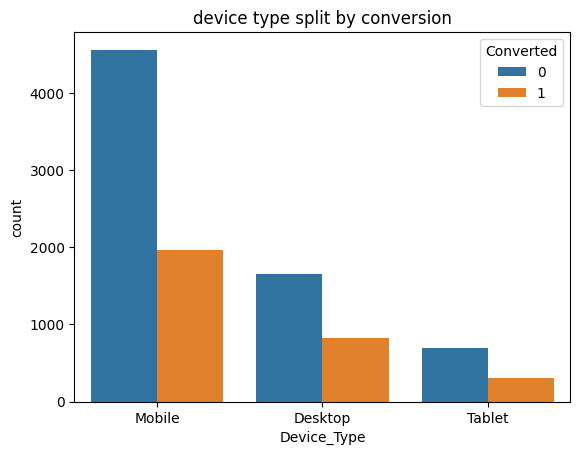

In [ ]:
# Relational Analysis: Compare a categorical object column against the target
sns.countplot(x = 'Device_Type', data = train , hue = 'Converted')
plt.title('device type split by conversion')
plt.show()

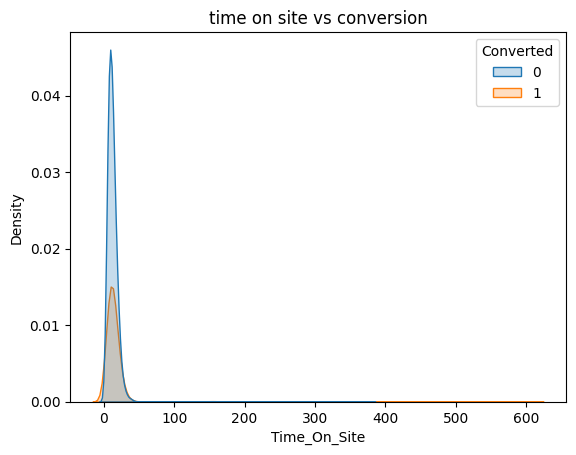

In [ ]:
sns.kdeplot( x = 'Time_On_Site',  hue ='Converted', data =train,fill =True)
plt.title('time on site vs conversion')
plt.show()


### Step 3: Define Features and Target

We separate the target column (`Converted`) from the rest of the features in the training set.
For simplicity, we only keep **numeric columns** in this baseline — categorical columns are dropped for now.
This keeps things easy to understand before we add more advanced preprocessing.


In [ ]:
from sklearn.preprocessing import StandardScaler , OrdinalEncoder
#we are not performing any label encoding for the categorical variable due to thier lack of importance in the prediction
TARGET = "Converted"

# Separate features and target
X_train_raw = train.drop(columns=[TARGET])
y_train = train[TARGET]
X_private_raw = private_test.drop(columns = ['User_ID'])

cat_columns = ['City_Tier', 'Device_Type','Traffic_Source','Browser_Version','Discount_Seen']
num_columns = ['Age','Income','Pages_Viewed','Products_Viewed','Time_On_Site','Campaign_Code']

X_train = pd.DataFrame(index = X_train_raw.index)
X_private = pd.DataFrame(index = X_private_raw.index )




### Step 4: Handle Missing Values & Scale Features

Real-world datasets often have missing values — we fill them in using the **median** of each column, which is robust to outliers.
After that, we apply **Standard Scaling** to bring all features onto the same scale, which is important for Logistic Regression to work well.
We fit both the imputer and scaler only on the training data, then apply the same transformation to the test data to avoid data leakage.


In [ ]:
# Fill missing values with the median of each column
num_imputer = SimpleImputer(strategy = 'median')


# Scale features to zero mean and unit variance
scaler = StandardScaler()

X_train_num_imputed= num_imputer.fit_transform(X_train_raw[num_columns])
X_private_num_imputed  = num_imputer.transform(X_private_raw[num_columns])

X_train[num_columns] = scaler.fit_transform(X_train_num_imputed)
X_private[num_columns] = scaler.transform(X_private_num_imputed)

#now lets impute for categorical columns

cat_imputer = SimpleImputer(strategy = 'constant',fill_value='Unknown')

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value =-1)



X_train_cat_imputed = cat_imputer.fit_transform(X_train_raw[cat_columns])
X_private_cat_imputed =cat_imputer.transform(X_private_raw[cat_columns])

X_train[cat_columns] = encoder.fit_transform(X_train_cat_imputed)
X_private[cat_columns] = encoder.transform(X_private_cat_imputed)




print(X_train.shape)
print(X_train.isna().sum())



(10000, 11)
Age                0
Income             0
Pages_Viewed       0
Products_Viewed    0
Time_On_Site       0
Campaign_Code      0
City_Tier          0
Device_Type        0
Traffic_Source     0
Browser_Version    0
Discount_Seen      0
dtype: int64


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import lightgbm as lgb
from sklearn.model_selection import train_test_split
#lets divide training and testing set!!
X_train_local,X_test_local  ,y_train_local ,y_test_local = train_test_split(X_train,
                                                                            y_train,
                                                                            test_size =0.2,
                                                                            random_state =42,
                                                                            stratify =y_train)
print(X_train_local.shape)
print(X_test_local.shape)
print('-'*60)


lr = LogisticRegression(max_iter=1000,
                        random_state=42
                         )
lr.fit(X_train_local, y_train_local)
lr_test_pred = lr.predict(X_test_local)




print("Model trained successfully!")
print("Training Accuracy: {:.4f}".format(lr.score(X_train_local, y_train_local)))
print('-'*30)
#lets use random forest
rfc = RandomForestClassifier(n_estimators=150,
                             max_depth = 10,
                             random_state =42,
                             class_weight = 'balanced',
                             n_jobs =-1)
rfc.fit(X_train_local , y_train_local)
rfc_test_pred = rfc.predict(X_test_local)
print('training F1 score:', f1_score(y_test_local,rfc_test_pred))
print('-'*30)
#lets use light gradient boosting machine (boosting technique)
lgb_model = lgb.LGBMClassifier(n_estimators=500,
                               max_depth = 8,
                               num_leaves = 15,
                               is_unbalance =True,
                               learning_rate = 0.04,
                               random_state =42
                               )
lgb_model.fit(X_train_local , y_train_local)
y_pred_lgb = lgb_model.predict(X_test_local)
print('training F1 score:', f1_score(y_test_local , y_pred_lgb , average ='macro'))




(8000, 11)
(2000, 11)
------------------------------------------------------------
Model trained successfully!
Training Accuracy: 0.7074
------------------------------
training F1 score: 0.5477707006369427
------------------------------
[LightGBM] [Info] Number of positive: 2470, number of negative: 5530
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000317 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 920
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.308750 -> initscore=-0.805970
[LightGBM] [Info] Start training from score -0.805970
training F1 score: 0.6295838992468206


### Step 6: Generate Predictions and Create Submission

We run the trained model on the scaled private test data to generate our final predictions.
The predictions are combined with the `User_ID` column into a DataFrame matching the required submission format.
The file is saved as `submission.csv` — just upload this to the competition portal to appear on the leaderboard!


In [ ]:
my_champion_model = lgb.LGBMClassifier(n_estimators=500,
                               max_depth = 8,
                               num_leaves = 15,
                               is_unbalance =True,
                               learning_rate = 0.04,
                               random_state =42

)


my_champion_model.fit(X_train,y_train)
predictions = my_champion_model.predict(X_private)

submission = pd.DataFrame({
    "User_ID": private_test["User_ID"],
    "Converted": predictions
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")
submission.head()


[LightGBM] [Info] Number of positive: 3087, number of negative: 6913
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002583 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 920
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.308700 -> initscore=-0.806204
[LightGBM] [Info] Start training from score -0.806204
submission.csv created successfully!


,User_ID,Converted
0,103001,0
1,103002,0
2,103003,1
3,103004,1
4,103005,0
